In [2]:
import nltk
from gensim.models import FastText
from keras.src.saving.saving_lib_test import FactorLayer
from torch.distributed.pipelining import pipeline

In [3]:
from nltk.tokenize import sent_tokenize, word_tokenize

In [4]:
example_string = """
Muad'Dib learned rapidly because his first training was in how to learn.
And the first lesson of all was the basic trust that he could learn.
It's shocking to find how many people do not believe they can learn,
and how many more believe learning to be difficult."""
sentences = sent_tokenize(example_string)
sentences, len(sentences)

(["\nMuad'Dib learned rapidly because his first training was in how to learn.",
  'And the first lesson of all was the basic trust that he could learn.',
  "It's shocking to find how many people do not believe they can learn,\nand how many more believe learning to be difficult."],
 3)

In [5]:
words = word_tokenize(sentences[0])
words

["Muad'Dib",
 'learned',
 'rapidly',
 'because',
 'his',
 'first',
 'training',
 'was',
 'in',
 'how',
 'to',
 'learn',
 '.']

## Filtering stop words

In [6]:
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/geraldamasi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
stopwords.words('english')[:10]

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

In [8]:
sentence = "This is a sample sentence, showing off the stop words filtration."
stop_words = set(stopwords.words('english'))
filtered_lst = [w for w in word_tokenize(sentence) if not w.lower() in stop_words]
filtered_lst, len(filtered_lst)

(['sample', 'sentence', ',', 'showing', 'stop', 'words', 'filtration', '.'], 8)

### Stemming and Lemmatization

Stemming is the process of reducing a word to its base or root form, while lemmatization is the process of reducing a word to its lemma, which is its dictionary form.

In [9]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

In [10]:
# Example of stemming
word = "running" #  Change here to any word you want to stem
stemmer.stem(word)

'run'

In [11]:
string_for_stem = "The crew of the USS Discovery discovered many discoveries. Discovering is what explorers do."
stemmed_words = [stemmer.stem(word) for word in word_tokenize(string_for_stem)]
stemmed_words, len(stemmed_words)

(['the',
  'crew',
  'of',
  'the',
  'uss',
  'discoveri',
  'discov',
  'mani',
  'discoveri',
  '.',
  'discov',
  'is',
  'what',
  'explor',
  'do',
  '.'],
 16)

## Tagging Parts of Speech (POS)

In [12]:
nltk.help.upenn_tagset()

$: dollar
    $ -$ --$ A$ C$ HK$ M$ NZ$ S$ U.S.$ US$
'': closing quotation mark
    ' ''
(: opening parenthesis
    ( [ {
): closing parenthesis
    ) ] }
,: comma
    ,
--: dash
    --
.: sentence terminator
    . ! ?
:: colon or ellipsis
    : ; ...
CC: conjunction, coordinating
    & 'n and both but either et for less minus neither nor or plus so
    therefore times v. versus vs. whether yet
CD: numeral, cardinal
    mid-1890 nine-thirty forty-two one-tenth ten million 0.5 one forty-
    seven 1987 twenty '79 zero two 78-degrees eighty-four IX '60s .025
    fifteen 271,124 dozen quintillion DM2,000 ...
DT: determiner
    all an another any both del each either every half la many much nary
    neither no some such that the them these this those
EX: existential there
    there
FW: foreign word
    gemeinschaft hund ich jeux habeas Haementeria Herr K'ang-si vous
    lutihaw alai je jour objets salutaris fille quibusdam pas trop Monte
    terram fiche oui corporis ...
IN: preposition or

In [13]:
sagan_quote = "The cosmos is all that is or ever was or ever will be."
tokens = word_tokenize(sagan_quote)
nltk.pos_tag(tokens)

[('The', 'DT'),
 ('cosmos', 'NN'),
 ('is', 'VBZ'),
 ('all', 'DT'),
 ('that', 'WDT'),
 ('is', 'VBZ'),
 ('or', 'CC'),
 ('ever', 'RB'),
 ('was', 'VBD'),
 ('or', 'CC'),
 ('ever', 'RB'),
 ('will', 'MD'),
 ('be', 'VB'),
 ('.', '.')]

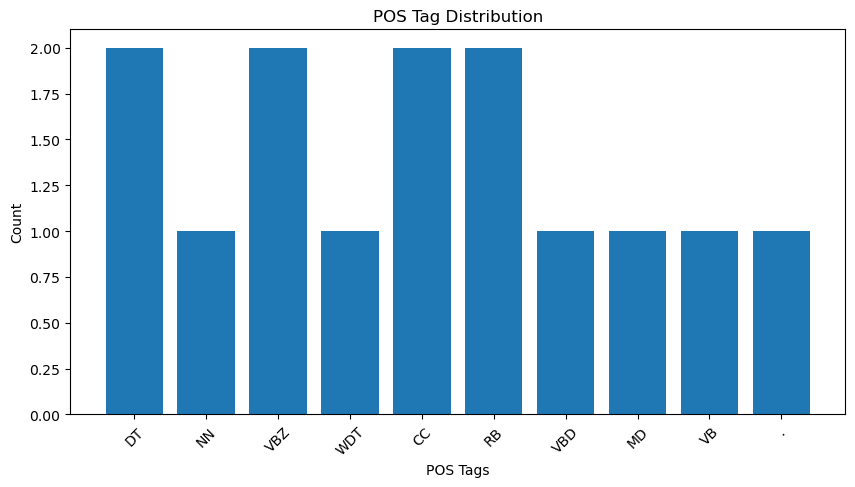

In [14]:
# Plot the POS tags
import matplotlib.pyplot as plt
from collections import Counter
pos_tags = nltk.pos_tag(tokens)
tag_counts = Counter(tag for word, tag in pos_tags)
plt.figure(figsize=(10, 5))
plt.bar(tag_counts.keys(), tag_counts.values())
plt.xlabel('POS Tags')
plt.ylabel('Count')
plt.title('POS Tag Distribution')
plt.xticks(rotation=45)
plt.show()

## Lemmatization

In [15]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
#Example of lemmatization
lemmatizer.lemmatize("discovering", pos='v')  # 'v' for verb

'discover'

In [16]:
# Example 2 of lemmatization using word very different from its lemma
print(lemmatizer.lemmatize("better")) # Default parameter for pos is noun
print(lemmatizer.lemmatize("better", pos='a'))  # 'a' for adjective

better
good


## Named Entity Recognition (NER)

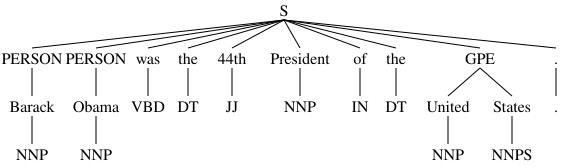

In [17]:
example_sentence = "Barack Obama was the 44th President of the United States."
# words = word_tokenize(example_sentence)
pos_tags = nltk.pos_tag(word_tokenize(example_sentence))
tree = nltk.ne_chunk(pos_tags)
tree

In [18]:
# Using the similar example_sentence let's extract NNP (proper nouns) and NNP (singular proper nouns)
nnp_nouns = [word for word, pos in pos_tags if pos in ['NNP', 'NNPS']]
nnp_nouns, len(nnp_nouns)

(['Barack', 'Obama', 'President', 'United', 'States'], 5)

In [19]:
pos_tags

[('Barack', 'NNP'),
 ('Obama', 'NNP'),
 ('was', 'VBD'),
 ('the', 'DT'),
 ('44th', 'JJ'),
 ('President', 'NNP'),
 ('of', 'IN'),
 ('the', 'DT'),
 ('United', 'NNP'),
 ('States', 'NNPS'),
 ('.', '.')]

## Getting text to analyze

In [20]:
from nltk.book import *

*** Introductory Examples for the NLTK Book ***
Loading text1, ..., text9 and sent1, ..., sent9
Type the name of the text or sentence to view it.
Type: 'texts()' or 'sents()' to list the materials.
text1: Moby Dick by Herman Melville 1851
text2: Sense and Sensibility by Jane Austen 1811
text3: The Book of Genesis
text4: Inaugural Address Corpus
text5: Chat Corpus
text6: Monty Python and the Holy Grail
text7: Wall Street Journal
text8: Personals Corpus
text9: The Man Who Was Thursday by G . K . Chesterton 1908


In [28]:
text1.concordance('monstrous')  # Find occurrences of the word 'monstrous' in text1)

Displaying 11 of 11 matches:
ong the former , one was of a most monstrous size . ... This came towards us , 
ON OF THE PSALMS . " Touching that monstrous bulk of the whale or ork we have r
ll over with a heathenish array of monstrous clubs and spears . Some were thick
d as you gazed , and wondered what monstrous cannibal and savage could ever hav
that has survived the flood ; most monstrous and most mountainous ! That Himmal
they might scout at Moby Dick as a monstrous fable , or still worse and more de
th of Radney .'" CHAPTER 55 Of the Monstrous Pictures of Whales . I shall ere l
ing Scenes . In connexion with the monstrous pictures of whales , I am strongly
ere to enter upon those still more monstrous stories of them which are to be fo
ght have been rummaged out of this monstrous cabinet there is no telling . But 
of Whale - Bones ; for Whales of a monstrous size are oftentimes cast up dead u


In [29]:
text1.similar('monstrous')

true contemptible christian abundant few part mean careful puzzled
mystifying passing curious loving wise doleful gamesome singular
delightfully perilous fearless


> I didn't understand concordance yet... This is TODO for me.

## Making a Dispersion Plot

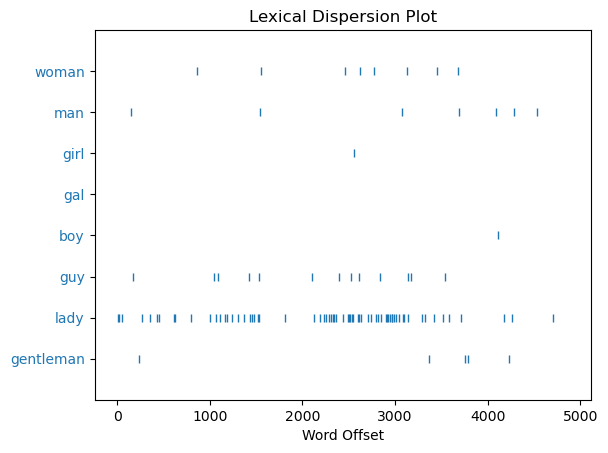

In [32]:
text8.dispersion_plot([
    'woman', 'man', 'girl', 'gal', 'boy', 'guy', 'lady', 'gentleman'
])

## Word Embeddings
Word embeddings are a type of word representation that allows words to be represented as vectors in a continuous vector space. This representation captures semantic relationships between words, allowing for more effective natural language processing tasks.

### One-Hot Encoding

In [43]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder
corpus = ['dog', 'cat', 'fish', 'bird', 'hamster']
corpus = np.array(corpus).reshape(-1, 1)
onehot_encoder = OneHotEncoder(sparse_output=False)
onehot_encoded = onehot_encoder.fit_transform(corpus)
print(onehot_encoded)

[[0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]]


### Bag of Words (BoW)

In [50]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
    'dog cat fish dog',
    'dog bird hamster',
    'cat fish bird dog fish',
    'hamster dog cat'
]
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(corpus).toarray()
print(bow_matrix), print(vectorizer.get_feature_names_out())

[[0 1 2 1 0]
 [1 0 1 0 1]
 [1 1 1 2 0]
 [0 1 1 0 1]]
['bird' 'cat' 'dog' 'fish' 'hamster']


(None, None)

## Term Frequency-Inverse Document Frequency (TF-IDF)

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [
    "This is the first document.",
    "This document is the second document.",
    "And this is the third one.",
    "Is this the first document?"
]
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus).toarray()
print(X), print(vectorizer.get_feature_names_out()), print(X.shape)

[[0.         0.46979139 0.58028582 0.38408524 0.         0.
  0.38408524 0.         0.38408524]
 [0.         0.6876236  0.         0.28108867 0.         0.53864762
  0.28108867 0.         0.28108867]
 [0.51184851 0.         0.         0.26710379 0.51184851 0.
  0.26710379 0.51184851 0.26710379]
 [0.         0.46979139 0.58028582 0.38408524 0.         0.
  0.38408524 0.         0.38408524]]
['and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']
(4, 9)


(None, None, None)

## Word2Vec

In [77]:
#TODO: Implement Word2Vec using Gensim or similar library
[word_tokenize(txt) for txt in corpus if isinstance(txt, str)]  # Tokenize the corpus

[['This', 'is', 'the', 'first', 'document', '.'],
 ['This', 'document', 'is', 'the', 'second', 'document', '.'],
 ['And', 'this', 'is', 'the', 'third', 'one', '.'],
 ['Is', 'this', 'the', 'first', 'document', '?']]

## GloVe (Global Vectors for Word Representation)

In [76]:
#TODO: Implement GloVe using Gensim or similar library


## ELMo (Embeddings from Language Models)

In [87]:
#TODO: Implement ELMo using Gensim or similar library

## BERT (Bidirectional Encoder Representations from Transformers)

In [89]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

text = "Hello, my name is Gerald and I am an AI engineer."
inputs = tokenizer(text, return_tensors='pt')

with torch.no_grad():
    outputs = model(**inputs)
    embeddings = outputs.last_hidden_state
print(embeddings.shape)

torch.Size([1, 15, 768])


In [94]:
tokens = tokenizer.tokenize(text)
token_ids = tokens.index('gerald') +1
embeddings[0, token_ids, :].numpy()  # Get the embedding for the token 'gerald'

array([-2.53468305e-01, -1.49605989e-01, -2.62277573e-01,  3.23870897e-01,
       -2.42451131e-01, -2.68941559e-02,  1.08067060e+00,  1.43989575e+00,
       -1.84293568e-01, -2.14041591e-01, -3.12145829e-01,  2.27315351e-04,
        6.51939213e-02,  6.24992251e-01, -2.94555068e-01, -2.09732741e-01,
        5.43638878e-02, -1.41933560e-01, -4.08522561e-02,  5.02733439e-02,
       -3.45703512e-01,  1.73076645e-01,  2.00509414e-01,  3.56661767e-01,
        9.93842632e-02,  1.01108813e+00, -4.37196940e-01,  1.07519698e+00,
       -1.34829366e+00, -8.62619698e-01, -2.55346924e-01, -9.39862430e-03,
        1.15875089e+00, -5.78041255e-01, -1.33394635e+00, -6.11194223e-03,
       -7.51510382e-01, -1.53842807e-01, -1.21329868e+00, -4.15397704e-01,
       -1.32326022e-01, -1.25612926e+00, -5.28901406e-02, -3.23996633e-01,
        4.62666154e-03, -1.85385287e-01,  8.45212281e-01, -5.53071260e-01,
       -7.39294067e-02, -9.86342728e-01, -5.32656074e-01,  2.68059880e-01,
       -3.38326693e-01, -

> BERT training simple example

In [3]:
from datasets import Dataset

texts = [
    "I love this movie!",
    "This film was awful.",
    "Amazing performance by the actors.",
    "The plot was very boring.",
    "What a great story!",
    "Terrible direction and bad acting."
]
labels = [1, 0, 1, 0, 1, 0]
dataset = Dataset.from_dict({"text": texts, "label": labels})
dataset

/opt/anaconda3/envs/NLP/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset({
    features: ['text', 'label'],
    num_rows: 6
})

In [4]:
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)
tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_datasets

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 6
})

In [10]:
from transformers import BertForSequenceClassification
from transformers import Trainer, TrainingArguments


model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps' if torch.backends.mps.is_available() else 'cpu')
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets,
)
trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/anaconda3/envs/NLP/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


TrainOutput(global_step=3, training_loss=0.5392904281616211, metrics={'train_runtime': 2.2545, 'train_samples_per_second': 7.984, 'train_steps_per_second': 1.331, 'total_flos': 1183999749120.0, 'train_loss': 0.5392904281616211, 'epoch': 3.0})

In [21]:
# Evaluate the model
inputs = tokenizer("The movie was poor.", return_tensors="pt", padding=True, truncation=True, max_length=32)
inputs = {k: v.to(model.device) for k, v in inputs.items()}
with torch.no_grad():
    logits = model(**inputs).logits
    predicted_class = logits.argmax(dim=1).item()

print("Predicted Label:", predicted_class)  # 1 = positive

Predicted Label: 0


` Another example of Using BERT for Question Answering Scenario`

In [53]:
from transformers import BertForQuestionAnswering, BertTokenizer

device = "mps" if torch.backends.mps.is_available() else "cpu"

tokenizer = BertTokenizer.from_pretrained('bert-large-uncased-whole-word-masking-finetuned-squad')
model = BertForQuestionAnswering.from_pretrained('bert-large-uncased-whole-word-masking-finetuned-squad').to(device)

context = "And God created the heaven and the earth. And the earth was without form, and void; and darkness was upon the face of the deep. And the Spirit of God moved upon the face of the waters."
question = "Who created the heaven and the earth?"
inputs = tokenizer(question, context, return_tensors='pt')
inputs = {k: v.to(device) for k, v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs)
start_scores = outputs.start_logits
end_scores = outputs.end_logits
start_index = start_scores.argmax()
end_index = end_scores.argmax() + 1
# answer = tokenizer.convert_tokens_to_string(tokenizer.convert_ids_to_tokens(inputs['input_ids'][0][start_index:end_index]))
tokens = inputs['input_ids'][0][start_index:end_index]
answer = tokenizer.decode(tokens, skip_special_tokens=True)
print("Question:", question)
print("Answer:", answer)

Some weights of the model checkpoint at bert-large-uncased-whole-word-masking-finetuned-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Question: Who created the heaven and the earth?
Answer: god


In [54]:
# Second question from the same context
question = "What moved upon the face of the waters?"
inputs = tokenizer(question, context, return_tensors='pt')
inputs = {k: v.to(device) for k, v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs)
start_scores = outputs.start_logits
end_scores = outputs.end_logits
start_index = start_scores.argmax()
end_index = end_scores.argmax() + 1
tokens = inputs['input_ids'][0][start_index:end_index]
answer = tokenizer.decode(tokens, skip_special_tokens=True)
print("Question:", question)
print("Answer:", answer)

Question: What moved upon the face of the waters?
Answer: the spirit of god


In [57]:
# Third question from different context
question = "Who is Gerald?"
inputs = tokenizer(question, context, return_tensors='pt')
inputs = {k: v.to(device) for k, v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs)
start_scores = outputs.start_logits
end_scores = outputs.end_logits
start_index = start_scores.argmax()
end_index = end_scores.argmax() + 1
tokens = inputs['input_ids'][0][start_index:end_index]
answer = tokenizer.decode(tokens, skip_special_tokens=True)
print("Question:", question)
print("Answer:", answer)

Question: Who is Gerald?
Answer: god


`Another example of BERT for Named Entity Recognition (NER)`

In [61]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import pipeline

model_name = 'dslim/bert-base-NER'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name).to(device)

ner_pipeline = pipeline('ner', model=model, tokenizer=tokenizer, aggregation_strategy='simple')
text = "Barack Obama was the 44th President of the United States."
entities = ner_pipeline(text)
[{'word': entity['word'], 'score': entity['score'], 'entity_group': entity['entity_group']} for entity in entities]

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


[{'word': 'Barack Obama', 'score': 0.9995328, 'entity_group': 'PER'},
 {'word': 'United States', 'score': 0.999509, 'entity_group': 'LOC'}]

In [62]:
text = "Albert Einstein was born in Ulm, Germany and worked at Princeton University."
entities = ner_pipeline(text)
[{'word': entity['word'], 'score': entity['score'], 'entity_group': entity['entity_group']} for entity in entities]

[{'word': 'Albert Einstein', 'score': 0.9983363, 'entity_group': 'PER'},
 {'word': 'Ulm', 'score': 0.9645325, 'entity_group': 'LOC'},
 {'word': 'Germany', 'score': 0.99968934, 'entity_group': 'LOC'},
 {'word': 'Princeton University', 'score': 0.9978423, 'entity_group': 'ORG'}]